# Diabetic Retinopathy CNN - LeakyReLU Colab Training

This experiment keeps the baseline architecture and training pipeline, replacing hidden-layer ReLU activations with LeakyReLU. The output layer remains Softmax and the integer directory labels use sparse categorical crossentropy.

In [ ]:
import sys
import subprocess
import importlib.util

if importlib.util.find_spec('tensorflow') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow'])

import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

## Mount Google Drive

In [2]:
try:
    from google.colab import drive
except ModuleNotFoundError:
    class LocalDrive:
        @staticmethod
        def mount(path):
            print("Google Drive mounting skipped: running outside Google Colab.")

    drive = LocalDrive()
drive.mount('/content/drive')

Google Drive mounting skipped: running outside Google Colab.


## Configure the dataset and experiment

In [14]:
from pathlib import Path

# Update this to the folder containing Mild, Moderate, No_DR, Proliferate_DR, and Severe.
DATA_DIR = Path('/content/drive/MyDrive/Deep-Learning-Assignment-Group-ID-5/data/gaussian_filtered_images')
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 5
NUM_CLASSES = 5
SEED = 42
EXPECTED_CLASSES = {'Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe'}

# Use the mounted Google Drive path in Colab, or a local project path otherwise.
colab_path = Path(
    '/content/drive/MyDrive/Deep-Learning-Assignment-Group-ID-5/'
    'data/gaussian_filtered_images'
)

local_candidates = [
    Path.cwd() / 'data' / 'gaussian_filtered_images',
    Path(
        r'C:\Users\Sadumina Rathnayaka\Desktop\DL My part'
        r'\Deep-Learning-Assignment-Group-ID-5\data\gaussian_filtered_images'
    ),
]

DATA_DIR = (
    colab_path
    if colab_path.is_dir()
    else next(
        (path for path in local_candidates if path.is_dir()),
        local_candidates[0]
    )
)

assert DATA_DIR.is_dir(), (
    f'Dataset folder not found: {DATA_DIR}\n'
    'Update DATA_DIR to the actual local dataset folder.'
)
found_classes = {path.name for path in DATA_DIR.iterdir() if path.is_dir()}
assert found_classes == EXPECTED_CLASSES, (
    f'Expected class folders {sorted(EXPECTED_CLASSES)}, found {sorted(found_classes)}'
)
print('Dataset:', DATA_DIR)
print('Class folders:', sorted(found_classes))

Dataset: c:\Users\Sadumina Rathnayaka\Desktop\DL My part\Deep-Learning-Assignment-Group-ID-5\data\gaussian_filtered_images
Class folders: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']


## Load and validate the image datasets

In [7]:
from tensorflow.keras import layers, models
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
assert len(class_names) == NUM_CLASSES
print('Classes:', class_names)

sample_images, sample_labels = next(iter(train_ds))
assert tuple(sample_images.shape[1:]) == (*IMG_SIZE, 3)
assert sample_labels.dtype.is_integer
assert int(tf.reduce_min(sample_labels)) >= 0
assert int(tf.reduce_max(sample_labels)) < NUM_CLASSES
print('Sample batch:', sample_images.shape, sample_labels.shape)

Found 3662 files belonging to 5 classes.
Using 2930 files for training.
Found 3662 files belonging to 5 classes.
Using 732 files for validation.
Classes: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
Sample batch: (32, 224, 224, 3) (32,)


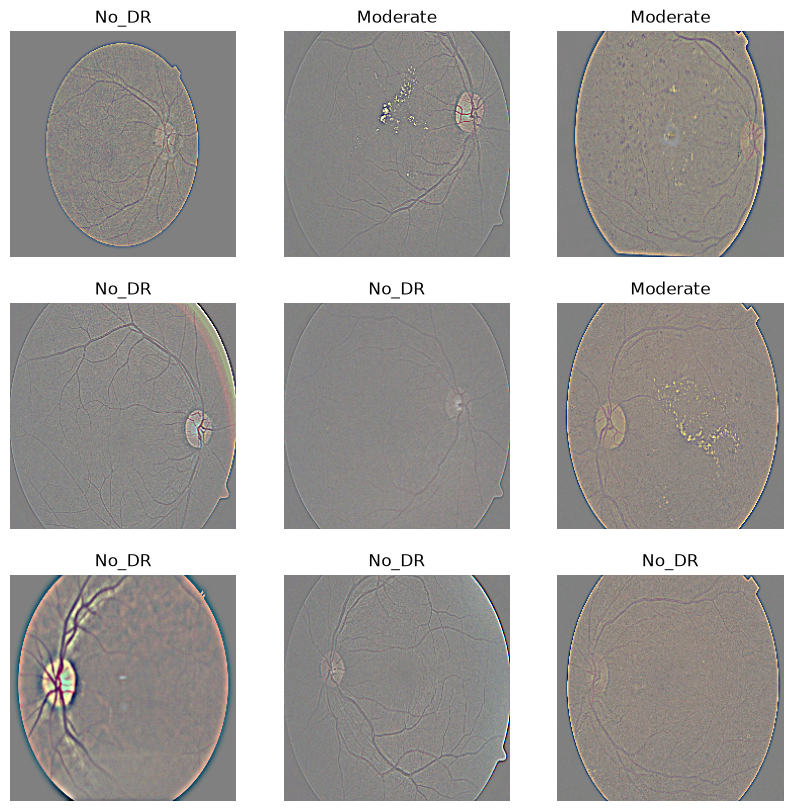

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[int(labels[i])])
        plt.axis('off')
plt.show()

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Build the LeakyReLU model

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='data_augmentation')

model = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, 3, padding='same'),
    layers.LeakyReLU(negative_slope=0.01),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same'),
    layers.LeakyReLU(negative_slope=0.01),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same'),
    layers.LeakyReLU(negative_slope=0.01),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, padding='same'),
    layers.LeakyReLU(negative_slope=0.01),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256),
    layers.LeakyReLU(negative_slope=0.01),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

assert model.output_shape == (None, NUM_CLASSES)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 457,413 (1.74 MB)

 Trainable params: 456,453 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

## Save the best alternative model

In [11]:
SAVE_DIR = Path('/content/drive/MyDrive/dr-cnn-models/leakyrelu')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = SAVE_DIR / 'best_leakyrelu_cnn.keras'

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_accuracy', save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3
    ),
]
print('Artifacts will be saved to:', SAVE_DIR)

Artifacts will be saved to: \content\drive\MyDrive\dr-cnn-models\leakyrelu


## Train

Run the next cell once the path and one-batch checks above pass.

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1354s 15s/step - accuracy: 0.6563 - loss: 0.9733 - val_accuracy: 0.2801 - val_loss: 1.7869 - learning_rate: 1.0000e-04
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 982s 3s/step - accuracy: 0.6792 - loss: 0.8903 - val_accuracy: 0.2801 - val_loss: 2.0436 - learning_rate: 1.0000e-04
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.6997 - loss: 0.8438 - val_accuracy: 0.0806 - val_loss: 1.9241 - learning_rate: 1.0000e-04
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1925s 21s/step - accuracy: 0.7123 - loss: 0.8022 - val_accuracy: 0.1230 - val_loss: 1.5915 - learning_rate: 1.0000e-04
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.7215 - loss: 0.7866 - val_accuracy: 0.3811 - val_loss: 1.4169 - learning_rate: 1.0000e-04


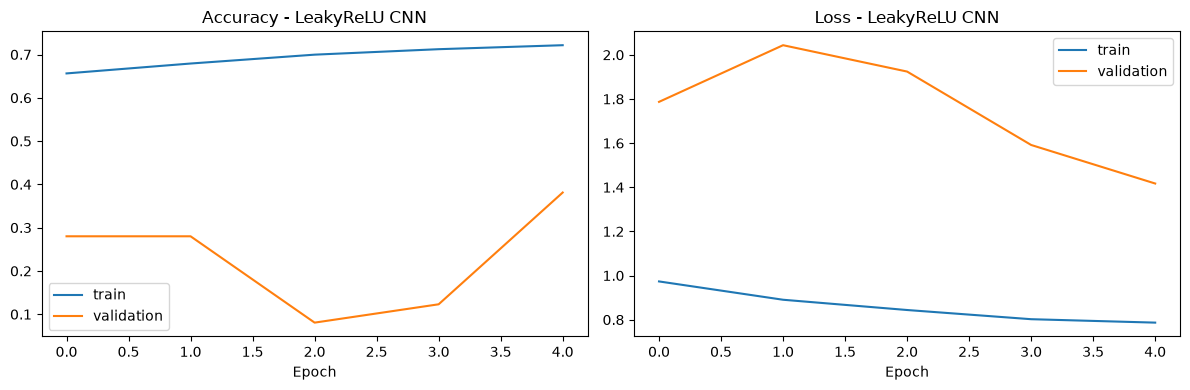

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Accuracy - LeakyReLU CNN')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Loss - LeakyReLU CNN')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig(SAVE_DIR / 'leakyrelu_training_curves.png')
plt.show()

## Classification report and confusion matrix

23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 343ms/step
                precision    recall  f1-score   support

          Mild       0.12      0.93      0.22        59
      Moderate       1.00      0.01      0.02       205
         No_DR       0.78      0.61      0.69       363
Proliferate_DR       0.00      0.00      0.00        59
        Severe       0.00      0.00      0.00        46

      accuracy                           0.38       732
     macro avg       0.38      0.31      0.18       732
  weighted avg       0.68      0.38      0.36       732



c:\Users\Sadumina Rathnayaka\Desktop\Reserach Dummy\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sadumina Rathnayaka\Desktop\Reserach Dummy\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sadumina Rathnayaka\Desktop\Reserach Dummy\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

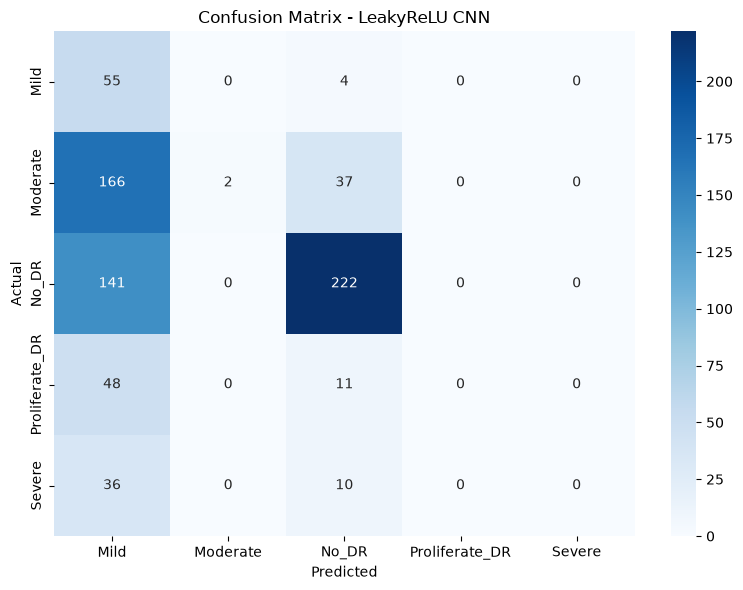

In [17]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

best_model = tf.keras.models.load_model(MODEL_PATH)
y_true = np.concatenate([labels.numpy() for _, labels in val_ds], axis=0)
y_pred_probs = best_model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LeakyReLU CNN')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'leakyrelu_confusion_matrix.png')
plt.show()